In [1]:
from typing import TypedDict, List
from config.llm import llm

class State(TypedDict):
    text: str
    classification: str
    entities: List[str]
    summary: str


/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_key is not default parameter.
                openai_api_key was transferred to model_kwargs.
                Please confirm that openai_api_key is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_base is not default parameter.
                openai_api_base was transferred to model_kwargs.
                Please confirm that openai_api_base is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [2]:
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage

# 判断文本属于哪个类别
def classification_node(state: State):
    prompt = PromptTemplate(
        input_variables=['text'],
        template="Classify the following text into one of the categories: News, Blog, Research, or Other.\n\nText:{text}\n\nCategory:"
    )

    message = HumanMessage(content=prompt.format(text=state['text']))
    classification = llm.invoke([message]).content.strip()
    return {"classification": classification}

In [3]:
# 实体提取节点：从文本里揪出人名、组织、地点
def entity_extraction_node(state: State):
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Extract all the entities (Person, Organization, Location) from the following text. Provide the result as a comma-separated list.\n\nText:{text}\n\nEntities:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    entities = llm.invoke([message]).content.strip().split(", ")
    return {"entities": entities}

In [4]:
# 摘要节点：一句话总结全文
def summarization_node(state: State):
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Summarize the following text in one short sentence.\n\nText:{text}\n\nSummary:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    summary = llm.invoke([message]).content.strip()
    return {"summary": summary}

In [5]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(State)

workflow.add_node("classification_node", classification_node)
workflow.add_node("entity_extraction_node", entity_extraction_node)
workflow.add_node("summarization_node", summarization_node)

workflow.set_entry_point("classification_node")
workflow.add_edge("classification_node", "entity_extraction_node")
workflow.add_edge("entity_extraction_node", "summarization_node")
workflow.add_edge("summarization_node", END)
app = workflow.compile()

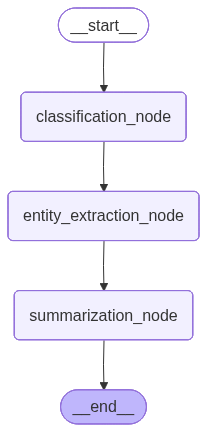

In [6]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [7]:
sample_text = """
OpenAI has announced the GPT-4 model, which is a large multimodal model
that exhibits human-level performance on various professional benchmarks.
It is developed to improve the alignment and safety of AI systems.
Additionally, the model is designed to be more efficient and scalable
than its predecessor, GPT-3.
"""

result = app.invoke({"text": sample_text})

print("Classification:", result["classification"])
print("Entities:", result["entities"])
print("Summary:", result["summary"])

Classification: News
Entities: ['OpenAI']
Summary: OpenAI has announced GPT-4, a safer and more efficient multimodal model demonstrating human-level performance.


In [8]:
class EnhancedState(TypedDict):
    text: str
    classification: str
    entities: List[str]
    summary: str
    sentiment: str          # 新增：情感分析结果

In [9]:
def sentiment_node(state: EnhancedState):
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Analyze the sentiment of the following text. Is it Positive, Negative, or Neutral?\n\nText:{text}\n\nSentiment:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    sentiment = llm.invoke([message]).content.strip()
    return {"sentiment": sentiment}

In [10]:
enhanced_workflow = StateGraph(EnhancedState)
enhanced_workflow.add_node("classification_node", classification_node)
enhanced_workflow.add_node("entity_extraction", entity_extraction_node)
enhanced_workflow.add_node("summarization", summarization_node)
enhanced_workflow.add_node("sentiment_analysis", sentiment_node)

enhanced_workflow.set_entry_point("classification_node")
enhanced_workflow.add_edge("classification_node", "entity_extraction")
enhanced_workflow.add_edge("entity_extraction", "summarization")
enhanced_workflow.add_edge("summarization", "sentiment_analysis")
enhanced_workflow.add_edge("sentiment_analysis", END)

enhanced_app = enhanced_workflow.compile()

In [11]:
result = enhanced_app.invoke({"text": sample_text})
print("Sentiment:", result["sentiment"])

KeyboardInterrupt: 

条件路由

In [12]:
def route_after_classification(state: EnhancedState) -> str:
    category = state["classification"].lower()
    return category in ["news", "research"]

In [13]:
conditional_workflow = StateGraph(EnhancedState)

conditional_workflow.add_node("classification_node", classification_node)
conditional_workflow.add_node("entity_extraction", entity_extraction_node)
conditional_workflow.add_node("summarization", summarization_node)
conditional_workflow.add_node("sentiment_analysis", sentiment_node)

conditional_workflow.set_entry_point("classification_node")

# 关键：条件路由
conditional_workflow.add_conditional_edges(
    "classification_node",
    route_after_classification,
    path_map={
        True: "entity_extraction",     # 新闻/论文 → 提取实体
        False: "summarization"         # 其他 → 直接摘要
    }
)

conditional_workflow.add_edge("entity_extraction", "summarization")
conditional_workflow.add_edge("summarization", "sentiment_analysis")
conditional_workflow.add_edge("sentiment_analysis", END)

conditional_app = conditional_workflow.compile()

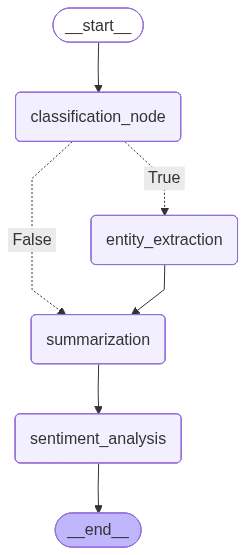

In [15]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

display(
    Image(
        conditional_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [18]:
news_text = """
OpenAI released the GPT-4 model with enhanced performance on academic
and professional tasks. It's seen as a major breakthrough in alignment
and reasoning capabilities.
"""

result = conditional_app.invoke({"text": news_text})
print("Classification:", result["classification"])
print("Entities:", result.get("entities", "Skipped"))
print("Sentiment:", result["sentiment"])


Classification: News
Entities: ['OpenAI']
Sentiment: Sentiment: Positive


In [17]:
blog_text = """
Here's what I learned from a week of meditating in silence.
No phones, no talking—just me, my breath, and some deep realizations.
"""

result = conditional_app.invoke({"text": blog_text})
print("Classification:", result["classification"])
print("Entities:", result.get("entities", "Skipped (not applicable)"))

Classification: Category: Blog
Entities: Skipped (not applicable)
